# Polynomial regression and the bias-variance tradeoff

### The decomposition everyone draws, measured instead

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a linear model fits a curve, how to split a test error into bias squared, variance and noise by resampling rather than by hand-waving, why the three parts add up exactly, and why the famous U-shaped curve is a claim about one training size and moves when that size changes |
| **You should already know** | [Linear regression](../01-linear-regression/) and [overfitting](../../01-foundations/03-overfitting-and-underfitting/) |
| **Datasets** | A synthetic curve with a known noise level, then California Housing |
| **Runtime** | Around three minutes on a laptop CPU |
| **Next** | [02-04 Ridge regression](../04-ridge-regression/), which is what you reach for once you have seen the variance column |

---

## 1. A curve out of a straight-line method

Polynomial regression sounds like a different model from linear regression. It
is not. It is the same model, handed different columns.

Give ordinary least squares a design matrix whose columns are $x$, $x^2$,
$x^3$ and so on, and it will fit a curve. The fit is still linear in the
coefficients, which is the only kind of linear that the phrase "linear model"
ever meant. Nothing about the solver changes. The normal equation from
[02-01](../01-linear-regression/) applies unaltered.

What does change is how much rope the model has. One column and it can only
draw a line. Twelve columns and it can pass through almost anything, including
the noise.

That trade has a name and a picture, and the picture is in every textbook. What
is almost never in the textbook is the measurement. The bias-variance
decomposition is usually drawn as two crossing curves with no numbers on either
axis. It is not a metaphor. It is an identity, and if you build a world where
you know the truth you can compute all three of its terms and watch them add up.

That is what this notebook does. Section 4 computes bias squared, variance and
noise separately, and checks the sum against the error actually observed.
Section 7 repeats the exercise on California Housing, where one of the three
terms becomes impossible to see, and says exactly which one and why.

## The world I can check against

The only way to measure bias is to know what the truth is. So the first six
sections use a function I wrote down, corrupted by noise I chose. Both are
printed below, and everything measured afterwards gets compared against them.

In [1]:
import sys
import pathlib
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

SIGMA = 0.45                 # the true noise standard deviation
X_LO, X_HI = -3.0, 3.0       # where the training points come from
N_TRAIN = 40                 # points in one training set
N_REPS = 400                 # training sets resampled per degree
DEGREES = np.arange(0, 13)


def truth(x):
    """The function the models are trying to recover.

    Deliberately not a polynomial. If it were, some degree in the sweep would
    have exactly zero bias and the decomposition would look tidier than any real
    problem ever does.
    """
    return np.sin(1.6 * x) + 0.35 * x


print(f"true noise sd, sigma         : {SIGMA}")
print(f"irreducible error, sigma^2   : {SIGMA ** 2:.4f}")
print(f"training points per fit      : {N_TRAIN}")
print(f"training sets per degree     : {N_REPS}")
print(f"degrees swept                : {DEGREES.min()} to {DEGREES.max()}")
print(f"x range                      : {X_LO} to {X_HI}")

true noise sd, sigma         : 0.45
irreducible error, sigma^2   : 0.2025
training points per fit      : 40
training sets per degree     : 400
degrees swept                : 0 to 12
x range                      : -3.0 to 3.0


## 2. The decomposition, written out

Fix a test input $x$. A training set $\mathcal{D}$ is random, so the fitted
function $\hat f_{\mathcal{D}}$ is random too. The observed target at $x$ is
$y = f(x) + \varepsilon$ with $\mathbb{E}[\varepsilon] = 0$ and
$\mathrm{Var}(\varepsilon) = \sigma^2$.

The expected squared error at $x$, over both the training draw and the noise on
the test point, splits into three:

$$\mathbb{E}\big[(y - \hat f_{\mathcal{D}}(x))^2\big]
= \underbrace{\big(\mathbb{E}[\hat f_{\mathcal{D}}(x)] - f(x)\big)^2}_{\text{bias}^2}
+ \underbrace{\mathrm{Var}\big(\hat f_{\mathcal{D}}(x)\big)}_{\text{variance}}
+ \underbrace{\sigma^2}_{\text{noise}}$$

The derivation is three lines and worth doing once. Write
$\bar f(x) = \mathbb{E}[\hat f_{\mathcal{D}}(x)]$ and add and subtract it:

$$y - \hat f = \underbrace{\varepsilon}_{\text{noise}} + \underbrace{(f - \bar f)}_{\text{bias}} + \underbrace{(\bar f - \hat f)}_{\text{deviation}}$$

Square it. Three squared terms and three cross terms. Every cross term dies:
$\varepsilon$ is independent of the training set and has mean zero, and
$\mathbb{E}[\bar f - \hat f] = 0$ by the definition of $\bar f$. What survives
is the identity above.

Two things follow immediately, and both are worth saying before any code runs.

**The noise term does not depend on the model.** No amount of flexibility, data
or cleverness touches it. It is the floor, and a test error at the floor is the
best result that exists rather than a suspiciously good one.

**Bias and variance are properties of a procedure, not of a fit.** Neither is
visible in a single trained model. Bias asks where the average fit over many
training sets lands. Variance asks how far one fit strays from that average.
You cannot see either without refitting, which is why almost nobody measures
them and almost everybody draws them.

## 3. From scratch: the design matrix is the whole trick

In [2]:
def poly_design(x, degree):
    """Vandermonde matrix in x, rescaled so the columns stay comparable.

    The rescale is not cosmetic. Over this x range the raw column x**12 spans
    about six orders of magnitude, and the least-squares solve spends most of its
    precision on that alone. Dividing by the half-width keeps every column
    inside [-1, 1].
    """
    z = np.asarray(x, dtype=float) / X_HI
    return np.vander(z, degree + 1, increasing=True)


def fit_poly(x, y, degree):
    """Least squares on the polynomial design. lstsq, not the normal equation.

    At high degree the design is close to rank deficient, and lstsq goes through
    an SVD that degrades gracefully where forming X.T @ X would square the
    condition number and fall over.
    """
    coef, *_ = np.linalg.lstsq(poly_design(x, degree), y, rcond=None)
    return coef


def predict_poly(coef, x):
    return poly_design(x, len(coef) - 1) @ coef


rng = np.random.default_rng(SEED)
x_demo = rng.uniform(X_LO, X_HI, N_TRAIN)
y_demo = truth(x_demo) + rng.normal(0, SIGMA, N_TRAIN)
grid = np.linspace(X_LO, X_HI, 400)

# A held-out sample large enough that its own Monte Carlo error is small.
x_far = rng.uniform(X_LO, X_HI, 20_000)
y_far = truth(x_far) + rng.normal(0, SIGMA, 20_000)

print(f"design matrix at degree 3: shape {poly_design(x_demo, 3).shape}, "
      f"columns are 1, z, z^2, z^3 with z = x / {X_HI:g}")
print(f"condition number, degree 3  : {np.linalg.cond(poly_design(x_demo, 3)):.1f}")
print(f"condition number, degree 12 : {np.linalg.cond(poly_design(x_demo, 12)):.1e}")

design matrix at degree 3: shape (40, 4), columns are 1, z, z^2, z^3 with z = x / 3
condition number, degree 3  : 8.0
condition number, degree 12 : 1.9e+04


### Checked against the library

scikit-learn builds the same columns with `PolynomialFeatures` and hands them
to the same least-squares routine. If my version disagrees with it, mine is
wrong.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

expand = PolynomialFeatures(degree=6)
theirs = LinearRegression().fit(expand.fit_transform(x_demo[:, None]), y_demo)

mine_grid = predict_poly(fit_poly(x_demo, y_demo, 6), grid)
theirs_grid = theirs.predict(expand.transform(grid[:, None]))

print(f"largest gap between my degree-6 fit and sklearn's, across the grid: "
      f"{np.abs(mine_grid - theirs_grid).max():.2e}")
print(f"sklearn built {expand.n_output_features_} columns for one input feature "
      f"at degree 6 (including the bias column it does not need here)")

largest gap between my degree-6 fit and sklearn's, across the grid: 1.73e-13
sklearn built 7 columns for one input feature at degree 6 (including the bias column it does not need here)


### What three degrees look like on one sample

One training sample, three models. The lowest degree cannot bend at all. The
highest bends toward individual points. The one in between is trying to be a
curve rather than a memory.

degree  1: held-out RMSE 0.882   (1.96x the noise floor)
degree  5: held-out RMSE 0.485   (1.08x the noise floor)
degree 12: held-out RMSE 0.511   (1.14x the noise floor)


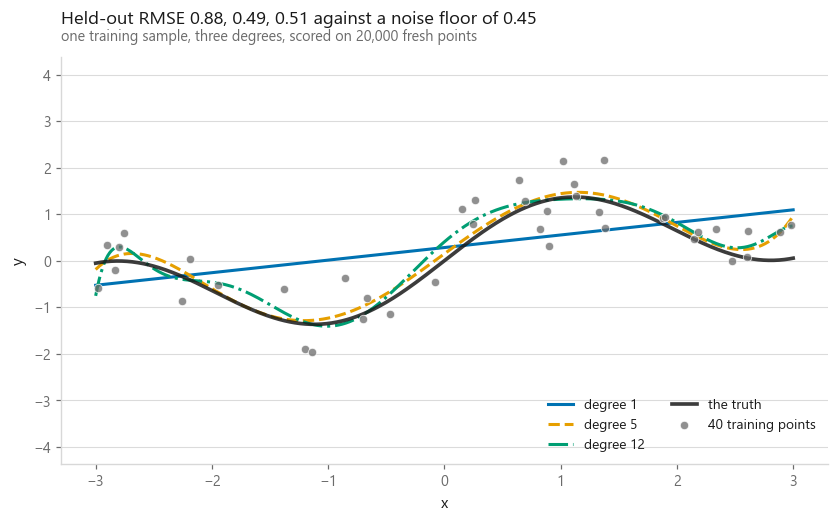

In [4]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))

shown = [1, 5, 12]
rmse = {}
for i, d in enumerate(shown):
    coef = fit_poly(x_demo, y_demo, d)
    rmse[d] = float(np.sqrt(np.mean((y_far - predict_poly(coef, x_far)) ** 2)))
    ax.plot(grid, predict_poly(coef, grid), color=style.PALETTE[i],
            ls=style.DASHES[i], lw=2.0, label=f"degree {d}")

ax.plot(grid, truth(grid), color=style.INK, lw=2.4, alpha=0.85, label="the truth")
ax.scatter(x_demo, y_demo, s=30, color=style.MUTED, alpha=0.75, zorder=3,
           edgecolor="white", linewidth=0.6, label=f"{N_TRAIN} training points")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(truth(grid).min() - 3.0, truth(grid).max() + 3.0)
ax.legend(loc="lower right", ncol=2, fontsize=9)
style.title(
    ax,
    f"Held-out RMSE {rmse[1]:.2f}, {rmse[5]:.2f}, {rmse[12]:.2f} against a noise floor of {SIGMA:.2f}",
    "one training sample, three degrees, scored on 20,000 fresh points")
style.save(fig, FIG / "fig-01-three-degrees.png")

for d in shown:
    print(f"degree {d:2d}: held-out RMSE {rmse[d]:.3f}   "
          f"({rmse[d] / SIGMA:.2f}x the noise floor)")

One sample tells you which degree won this time. It does not tell you why, and
it cannot separate a model that is systematically wrong from one that is
unlucky. For that I need many samples.

## 4. Measuring all three terms

The recipe follows the definitions directly.

Draw many training sets from the same generator. Fit every degree on every one
of them. Predict on a fixed grid of test inputs. Then, at each test input:

- the **average prediction** across training sets estimates $\bar f(x)$
- **bias squared** is the gap between that average and the truth, squared
- **variance** is the spread of the individual predictions about their own average
- **noise** is $\sigma^2$, which I chose and therefore know

Separately, and without using any of the above, I measure the error that
actually occurs: predict on freshly noised test targets and average the squared
error. If the identity in section 2 is right, the two agree.

One detail that is easy to get wrong and pleasant once seen. The plug-in bias
squared uses the *sample* mean of the predictions, so it is inflated by
roughly variance divided by the number of replicates. The plug-in variance,
computed about that same sample mean, is deflated by exactly the same amount.
They cancel. The sum is unbiased even though neither part is, which is why the
check below can be tight with a moderate number of replicates.

In [5]:
def decompose(degrees, n_train, n_reps, seed, sigma=SIGMA, n_test=400):
    """Empirical bias-variance-noise split for each degree.

    Every degree is fitted on the *same* list of training sets, so the comparison
    across degrees is paired and most of the Monte Carlo wobble is shared rather
    than added.
    """
    rng = np.random.default_rng(seed)
    x_test = np.linspace(X_LO, X_HI, n_test)
    f_test = truth(x_test)

    samples = []
    for _ in range(n_reps):
        x_tr = rng.uniform(X_LO, X_HI, n_train)
        samples.append((x_tr, truth(x_tr) + rng.normal(0, sigma, n_train)))

    # Fresh noise on the test targets, one draw per replicate. This is what makes
    # the measured column an independent check rather than a restatement.
    noise_test = rng.normal(0, sigma, (n_reps, n_test))

    rows, pointwise = [], {}
    for d in degrees:
        preds = np.array([predict_poly(fit_poly(x_tr, y_tr, d), x_test)
                          for x_tr, y_tr in samples])
        mean_pred = preds.mean(axis=0)
        bias2_x = (mean_pred - f_test) ** 2
        var_x = preds.var(axis=0)
        measured = float(np.mean((f_test + noise_test - preds) ** 2))

        rows.append({"degree": int(d),
                     "bias squared": float(bias2_x.mean()),
                     "variance": float(var_x.mean()),
                     "noise": sigma ** 2,
                     "sum of three": float(bias2_x.mean() + var_x.mean() + sigma ** 2),
                     "measured": measured})
        pointwise[int(d)] = (x_test, bias2_x, var_x)

    return pd.DataFrame(rows), pointwise


dec, pointwise = decompose(DEGREES, N_TRAIN, N_REPS, seed=SEED)
dec["gap %"] = 100 * (dec["sum of three"] - dec["measured"]).abs() / dec["measured"]

# The plug-in bias squared is inflated by variance / N_REPS, as the paragraph
# above says. Print that inflation next to it, because any bias squared smaller
# than its own inflation is not a measurement of bias and must not be compared.
dec["bias2 inflation"] = dec["variance"] / N_REPS
dec["bias2 readable"] = dec["bias squared"] > 3 * dec["bias2 inflation"]

print(dec.to_string(index=False, float_format="{:.4f}".format))
print("\ndegrees where bias squared is at least 3x its own plug-in inflation, "
      "and therefore worth comparing:")
print(f"  {dec.loc[dec['bias2 readable'], 'degree'].tolist()}")

 degree  bias squared  variance  noise  sum of three  measured  gap %  bias2 inflation  bias2 readable
      0        0.7457    0.0266 0.2025        0.9748    0.9754 0.0612           0.0001            True
      1        0.4985    0.0380 0.2025        0.7390    0.7386 0.0464           0.0001            True
      2        0.5000    0.0726 0.2025        0.7750    0.7740 0.1298           0.0002            True
      3        0.1053    0.0446 0.2025        0.3524    0.3516 0.2182           0.0001            True
      4        0.1098    0.0991 0.2025        0.4114    0.4108 0.1462           0.0002            True
      5        0.0038    0.0518 0.2025        0.2581    0.2586 0.1627           0.0001            True
      6        0.0054    0.1125 0.2025        0.3204    0.3203 0.0255           0.0003            True
      7        0.0007    0.2557 0.2025        0.4589    0.4595 0.1173           0.0006           False
      8        0.0008    0.8707 0.2025        1.0740    1.0767 0.2503    

In [6]:
best = dec.loc[dec["measured"].idxmin()]
worst_gap = dec["gap %"].max()

print(f"lowest measured test MSE at degree {int(best['degree'])}, "
      f"at {best['measured']:.4f}")
print(f"the noise floor alone is                     {SIGMA ** 2:.4f}")
print(f"so the best model is {best['measured'] / SIGMA ** 2:.2f}x the floor, and "
      f"{best['measured'] - SIGMA ** 2:.4f} of that is on the model")
print(f"\nworst disagreement between the three parts and the measured error: "
      f"{worst_gap:.2f}%")
print(f"median disagreement: {dec['gap %'].median():.2f}%")

lowest measured test MSE at degree 5, at 0.2586
the noise floor alone is                     0.2025
so the best model is 1.28x the floor, and 0.0561 of that is on the model

worst disagreement between the three parts and the measured error: 0.25%
median disagreement: 0.12%


The right-hand columns are the point of this notebook. Bias squared, variance
and the noise floor were computed from three different quantities, none of
which looked at the measured column, and they reproduce it.

Now a warning about reading the bias column, because the sum being right does
not make every part of it separately readable. The plug-in bias squared carries
an upward inflation of variance over the replicate count, and at high degree the
variance is enormous. So at the top of the sweep the inflation is larger than the
bias squared it is inflating, and those rows carry no information about bias at
all. The list printed under the table says which degrees survive that test. Read
the bias column only there.

This is the general trap with the decomposition rather than a quirk of this run.
The two plug-in terms cancel in the sum, which is why the identity check is
tight, and they do not cancel individually. A tight sum is not permission to
compare small differences in either part.

Now the shape. The absolute scale runs over several orders of magnitude, so the
left panel is on a log axis. The right panel drops the units and shows each
term as a share of the total, which is where the handover is easiest to see.

 degree  bias squared  variance  noise
      0         0.765     0.027  0.208
      1         0.675     0.051  0.274
      2         0.645     0.094  0.261
      3         0.299     0.127  0.575
      4         0.267     0.241  0.492
      5         0.015     0.201  0.784
      6         0.017     0.351  0.632
      7         0.002     0.557  0.441
      8         0.001     0.811  0.189
      9         0.002     0.925  0.073
     10         0.001     0.991  0.008
     11         0.000     0.998  0.001
     12         0.002     0.998  0.001


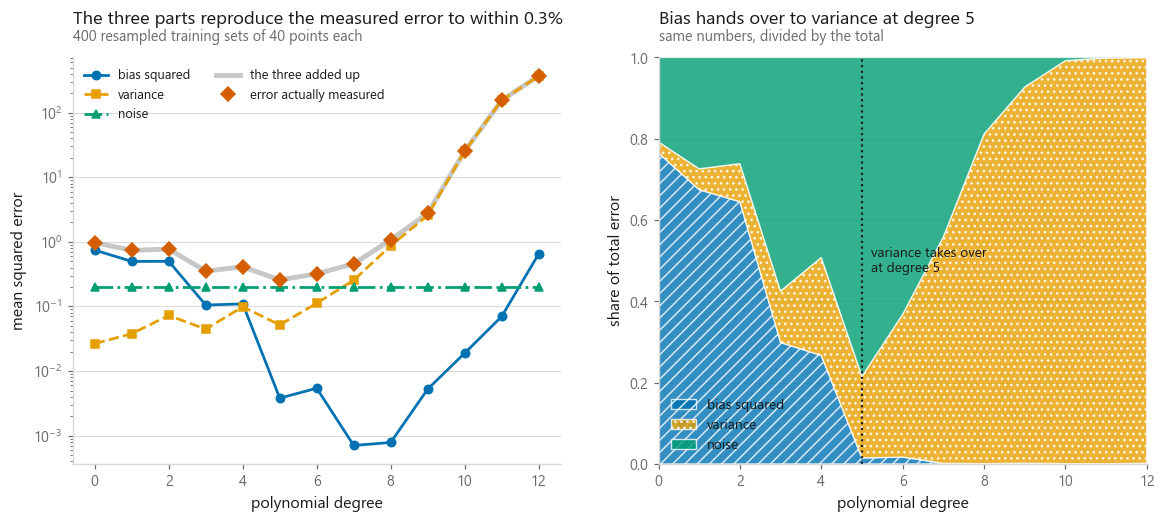

In [7]:
share = dec[["bias squared", "variance", "noise"]].div(dec["sum of three"], axis=0)
var_wins = dec.loc[share["variance"].to_numpy() > share["bias squared"].to_numpy(), "degree"]
crossover = int(var_wins.min())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

ax = axes[0]
parts = [("bias squared", style.PALETTE[0], style.MARKERS[0], "-"),
         ("variance", style.PALETTE[1], style.MARKERS[1], "--"),
         ("noise", style.PALETTE[2], style.MARKERS[2], "-.")]
for name, colour, marker, dash in parts:
    ax.plot(dec["degree"], dec[name], color=colour, ls=dash, marker=marker,
            lw=1.8, label=name)
ax.plot(dec["degree"], dec["sum of three"], color=style.NEUTRAL, lw=3.2, alpha=0.7,
        zorder=1, label="the three added up")
ax.plot(dec["degree"], dec["measured"], color=style.HIGHLIGHT, ls="none",
        marker=style.MARKERS[3], markersize=6.5, label="error actually measured")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error")
ax.legend(fontsize=8.5, loc="upper left", ncol=2)
style.title(ax, f"The three parts reproduce the measured error to within {worst_gap:.1f}%",
            f"{N_REPS} resampled training sets of {N_TRAIN} points each")

ax = axes[1]
lo = np.zeros(len(dec))
bands = [("bias squared", style.PALETTE[0], "///"),
         ("variance", style.PALETTE[1], "..."),
         ("noise", style.PALETTE[2], "")]
for name, colour, hatch in bands:
    hi = lo + share[name].to_numpy()
    ax.fill_between(dec["degree"], lo, hi, color=colour, alpha=0.80, hatch=hatch,
                    edgecolor="white", linewidth=0.9, label=name)
    lo = hi
ax.axvline(crossover, color=style.INK, lw=1.4, ls=":")
ax.annotate(f"variance takes over\nat degree {crossover}", xy=(crossover, 0.5),
            xytext=(6, 0), textcoords="offset points", fontsize=9, color=style.INK,
            va="center")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("share of total error")
ax.set_ylim(0, 1)
ax.set_xlim(dec["degree"].min(), dec["degree"].max())
ax.legend(fontsize=9, loc="lower left")
style.title(ax, f"Bias hands over to variance at degree {crossover}",
            "same numbers, divided by the total")

style.save(fig, FIG / "fig-02-decomposition.png")

print(share.assign(degree=dec["degree"])[["degree", "bias squared", "variance", "noise"]]
      .to_string(index=False, float_format="{:.3f}".format))

Read the right panel from left to right and the whole tradeoff is one picture.
At low degree the error is nearly all bias: the model is wrong in the same way
every time, and the noise floor is a thin strip at the bottom because there is
so much other error above it. As degree rises the bias band collapses, the
noise band grows as a share because the total is shrinking, and then variance
arrives and eats everything.

The floor is the part I want to point at. In absolute terms the noise never
moves. It is a horizontal line in the left panel and it will still be there
under any model, any dataset size, and any amount of tuning.

## 5. Where the variance actually lives

The numbers above are averages over the whole test range, which hides
something. Variance is not spread evenly across $x$. High-degree polynomials
are pinned down in the middle of the training range, where points are dense on
both sides, and free to swing at the edges, where there is data on one side
only.

degree  3: variance at the edges 0.0902, in the middle 0.0235, ratio 3.8
degree 12: variance at the edges 1233.7615, in the middle 0.0586, ratio 21050.0


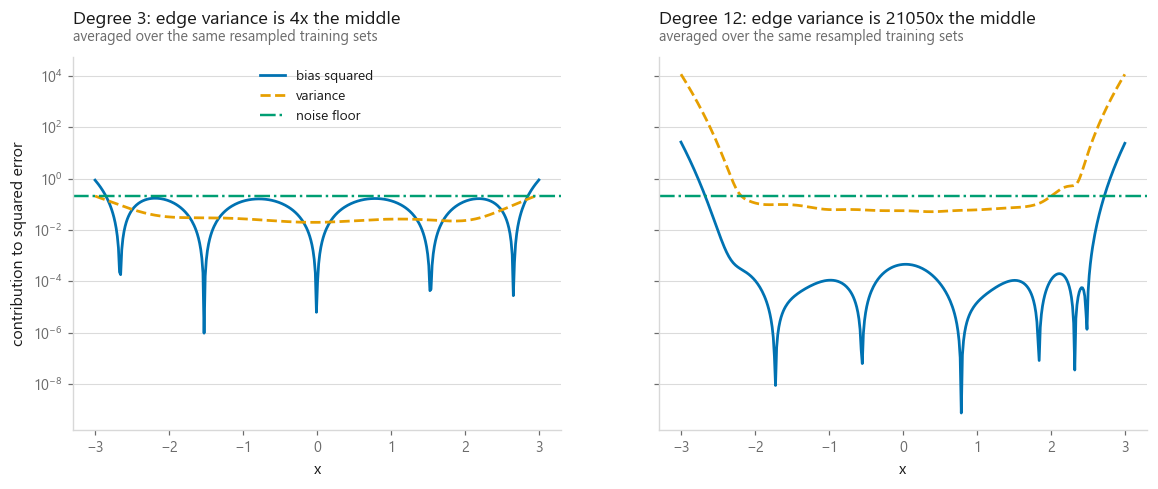

In [8]:
LOW_D, HIGH_D = 3, 12
x_test, _, _ = pointwise[LOW_D]
edge = (x_test < X_LO + 0.15 * (X_HI - X_LO)) | (x_test > X_HI - 0.15 * (X_HI - X_LO))
centre = np.abs(x_test) < 0.20 * (X_HI - X_LO)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4), sharey=True)
ratios = {}
for ax, d in zip(axes, [LOW_D, HIGH_D]):
    xs, bias2_x, var_x = pointwise[d]
    ratios[d] = float(var_x[edge].mean() / var_x[centre].mean())
    ax.plot(xs, bias2_x, color=style.PALETTE[0], ls="-", lw=1.8, label="bias squared")
    ax.plot(xs, var_x, color=style.PALETTE[1], ls="--", lw=1.8, label="variance")
    ax.axhline(SIGMA ** 2, color=style.PALETTE[2], ls="-.", lw=1.6, label="noise floor")
    ax.set_yscale("log")
    ax.set_xlabel("x")
    style.title(ax, f"Degree {d}: edge variance is {ratios[d]:.0f}x the middle",
                "averaged over the same resampled training sets")

axes[0].set_ylabel("contribution to squared error")
axes[0].legend(fontsize=9, loc="upper center")
style.save(fig, FIG / "fig-03-where-the-variance-lives.png")

for d in [LOW_D, HIGH_D]:
    xs, bias2_x, var_x = pointwise[d]
    print(f"degree {d:2d}: variance at the edges {var_x[edge].mean():.4f}, "
          f"in the middle {var_x[centre].mean():.4f}, ratio {ratios[d]:.1f}")

I expected the edge effect and I did not expect it to be that lopsided. It is
the practical reason a polynomial fit should never be trusted near the ends of
its training range, and the reason extrapolating one is close to meaningless:
just past the last data point, the variance that is already large at the edge
keeps growing without anything to hold it down.

It also explains a mismatch people run into. A model can have a perfectly
reasonable average test error and still be wildly unreliable on the part of the
input space you care about. The average hides it. The pointwise curve does not.

## 6. The U-curve is a claim about one training size

Every version of this chart I have seen shows test error falling, bottoming
out, and rising, with a single best degree marked. That curve is real, and it
is conditional on a number that is almost never stated: how much training data
there was.

Variance falls roughly as one over the sample size. Bias does not fall at all,
because bias is what the model class cannot represent no matter how much
evidence arrives. So growing the training set shrinks one arm of the U and
leaves the other alone, and the minimum slides to the right.

In [9]:
SIZES = [20, 40, 80, 160, 320]
SWEEP_REPS = 200

sweep, sizes_pointwise = [], {}
for n in SIZES:
    frame, _ = decompose(DEGREES, n, SWEEP_REPS, seed=SEED + n)
    sizes_pointwise[n] = frame
    row = frame.loc[frame["measured"].idxmin()]
    sweep.append({"training size": n,
                  "best degree": int(row["degree"]),
                  "best test MSE": row["measured"],
                  "bias squared there": row["bias squared"],
                  "variance there": row["variance"]})

sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False, float_format="{:.4f}".format))

# An argmin over a Monte Carlo estimate is only a finding if the bottom of the
# curve is actually pointed. Print how many degrees sit within 2% of each minimum,
# so "the best degree moved" can be told apart from "the plateau moved".
print("\ndegrees within 2% of each curve's own minimum:")
for n in SIZES:
    frame = sizes_pointwise[n]
    floor_ = frame["measured"].min()
    near = frame.loc[frame["measured"] <= 1.02 * floor_, "degree"].tolist()
    print(f"  n = {n:>3}: {near}")

 training size  best degree  best test MSE  bias squared there  variance there
            20            3         0.4572              0.1084          0.1484
            40            5         0.2588              0.0044          0.0523
            80            5         0.2259              0.0033          0.0192
           160            7         0.2139              0.0001          0.0109
           320            7         0.2071              0.0000          0.0055

degrees within 2% of each curve's own minimum:
  n =  20: [3]
  n =  40: [5]
  n =  80: [5]
  n = 160: [5, 6, 7, 8]
  n = 320: [5, 6, 7, 8, 9, 10, 11, 12]


n = 20: best degree 3, test MSE 0.4572
n = 320: best degree 7, test MSE 0.2071
variance at the best degree fell from 0.1484 to 0.0055
bias squared at the best degree went from 0.1084 to 0.0000


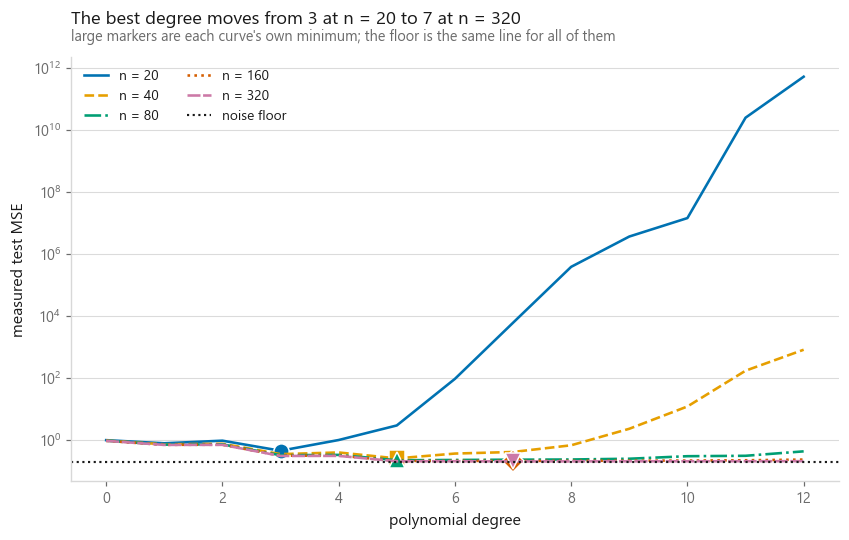

In [10]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))

for i, n in enumerate(SIZES):
    frame = sizes_pointwise[n]
    ax.plot(frame["degree"], frame["measured"], color=style.PALETTE[i],
            ls=style.DASHES[i % len(style.DASHES)], lw=1.7, label=f"n = {n}")
    row = frame.loc[frame["measured"].idxmin()]
    ax.plot(row["degree"], row["measured"], marker=style.MARKERS[i],
            color=style.PALETTE[i], markersize=10, markeredgecolor="white")

ax.axhline(SIGMA ** 2, color=style.INK, lw=1.4, ls=":", label="noise floor")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("measured test MSE")
ax.legend(fontsize=9, ncol=2, loc="upper left")
style.title(
    ax,
    f"The best degree moves from {sweep['best degree'].iloc[0]} at n = {SIZES[0]} "
    f"to {sweep['best degree'].iloc[-1]} at n = {SIZES[-1]}",
    "large markers are each curve's own minimum; the floor is the same line for all of them")
style.save(fig, FIG / "fig-04-training-size.png")

first, last = sweep.iloc[0], sweep.iloc[-1]
print(f"n = {int(first['training size'])}: best degree {int(first['best degree'])}, "
      f"test MSE {first['best test MSE']:.4f}")
print(f"n = {int(last['training size'])}: best degree {int(last['best degree'])}, "
      f"test MSE {last['best test MSE']:.4f}")
print(f"variance at the best degree fell from {first['variance there']:.4f} "
      f"to {last['variance there']:.4f}")
print(f"bias squared at the best degree went from {first['bias squared there']:.4f} "
      f"to {last['bias squared there']:.4f}")

Two things in that table, and one of them surprised me.

The expected one: the minimum moves right as the sample grows. The complexity
that was reckless at the smallest sample is affordable at the largest, because
there is now enough evidence to pin its coefficients down.

Before leaning on a single argmin, read the list printed under the table. It
gives the degrees within two percent of each curve's own minimum, which is the
difference between a pointed bottom and a plateau. The claim worth making is
about the plateau rather than about its lowest pixel: the whole band of
acceptable degrees shifts right as the sample grows, and picking any degree
inside a band costs almost nothing. Reporting "the optimal degree is 5" when
degrees 4 through 7 are within two percent of each other is the same mistake as
ranking models a thousandth apart.

The one I had not thought through: the whole curve does not shift down
uniformly. At low degree the curves are almost on top of each other, because a
low-degree fit is bias-dominated and more data does nothing about bias. The
curves separate only at the right-hand end, where variance is what is being
paid. More data is a variance treatment, and the chart shows exactly which
part of the model space it treats.

## 7. On real data, where one term disappears

Everything above depended on knowing `truth` and `SIGMA`. On California Housing
I know neither. So how much of the decomposition survives?

More than you might guess, and less than you want.

Take a fixed test set and resample training sets from a disjoint pool, exactly
as before. For each test point, the average squared error over replicates
splits **exactly**, with no approximation and no assumption:

$$\frac{1}{B}\sum_b \big(y_i - \hat f_b(x_i)\big)^2
= \big(y_i - \bar f(x_i)\big)^2 + \frac{1}{B}\sum_b \big(\hat f_b(x_i) - \bar f(x_i)\big)^2$$

The second term is the variance and it is fully measurable. The first term is
everything else: bias squared and noise, welded together, because $y_i$ is the
truth plus noise and nothing available separates them.

So on real data you get two of the three numbers. Variance, exactly. And a
lump. Splitting the lump needs either repeated observations at identical
inputs, which tabular data almost never has, or an assumption about the noise,
which is the thing you were trying to avoid assuming.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

CAL_COLS = ["MedInc", "HouseAge", "Latitude"]
CAL_DEGREES = list(range(1, 8))
CAL_N_TRAIN = 1000
CAL_REPS = 40

X_cal, y_cal = datasets.california_housing()
X_cal = X_cal[CAL_COLS]

pool_X, test_X, pool_y, test_y = train_test_split(
    X_cal.to_numpy(dtype=float), y_cal.to_numpy(dtype=float),
    test_size=4000, random_state=SEED)

rng_cal = np.random.default_rng(SEED)
draws = [rng_cal.choice(len(pool_y), CAL_N_TRAIN, replace=False) for _ in range(CAL_REPS)]

print(f"three columns kept: {CAL_COLS}")
print(f"pool {len(pool_y)} rows, {CAL_REPS} training sets of {CAL_N_TRAIN} drawn from it, "
      f"fixed test set of {len(test_y)}")

# Terms grow combinatorially in the feature count, which is why three columns and
# not eight. The table is the reason polynomial expansion stops being an option
# on wide data long before it stops being a good idea.
counts = pd.DataFrame(
    [{"features": p, **{f"degree {d}": math.comb(p + d, d) - 1 for d in [2, 4, 6, 8]}}
     for p in [1, 3, 8, 30]])
print("\nnumber of polynomial terms, excluding the intercept")
print(counts.to_string(index=False))

three columns kept: ['MedInc', 'HouseAge', 'Latitude']
pool 16640 rows, 40 training sets of 1000 drawn from it, fixed test set of 4000

number of polynomial terms, excluding the intercept
 features  degree 2  degree 4  degree 6  degree 8
        1         2         4         6         8
        3         9        34        83       164
        8        44       494      3002     12869
       30       495     46375   1947791  48903491


In [12]:
cal_rows = []
for d in CAL_DEGREES:
    # MinMax to [-1, 1] before the expansion, so that raising a column to the
    # eighth power cannot manufacture a number with eight extra digits in it.
    model = make_pipeline(MinMaxScaler(feature_range=(-1, 1)),
                          PolynomialFeatures(degree=d, include_bias=False),
                          LinearRegression())
    preds = np.array([model.fit(pool_X[idx], pool_y[idx]).predict(test_X)
                      for idx in draws])
    mean_pred = preds.mean(axis=0)
    variance = float(preds.var(axis=0).mean())
    lumped = float(((test_y - mean_pred) ** 2).mean())
    total = float(((test_y - preds) ** 2).mean())
    cal_rows.append({"degree": d,
                     "terms": math.comb(len(CAL_COLS) + d, d) - 1,
                     "bias squared + noise": lumped,
                     "variance": variance,
                     "sum": lumped + variance,
                     "measured": total})

cal = pd.DataFrame(cal_rows)
cal["identity residual"] = (cal["sum"] - cal["measured"]).abs()
print(cal.to_string(index=False, float_format="{:.5f}".format))
print(f"\nlargest residual on the exact identity: {cal['identity residual'].max():.2e}")

 degree  terms  bias squared + noise  variance      sum  measured  identity residual
      1      3               0.66309   0.00269  0.66578   0.66578            0.00000
      2      9               0.64681   0.00631  0.65312   0.65312            0.00000
      3     19               0.61456   0.01192  0.62648   0.62648            0.00000
      4     34               0.60328   0.03321  0.63649   0.63649            0.00000
      5     55               0.59394   0.17219  0.76613   0.76613            0.00000
      6     83               0.69051   1.78809  2.47860   2.47860            0.00000
      7    119               2.92619  56.71331 59.63950  59.63950            0.00000

largest residual on the exact identity: 7.11e-15


best degree 3: measured 0.6265, variance share 1.9%
highest degree 7: measured 59.6395, variance share 95.1%
lowest lumped bias-plus-noise seen anywhere in the sweep: 0.5939


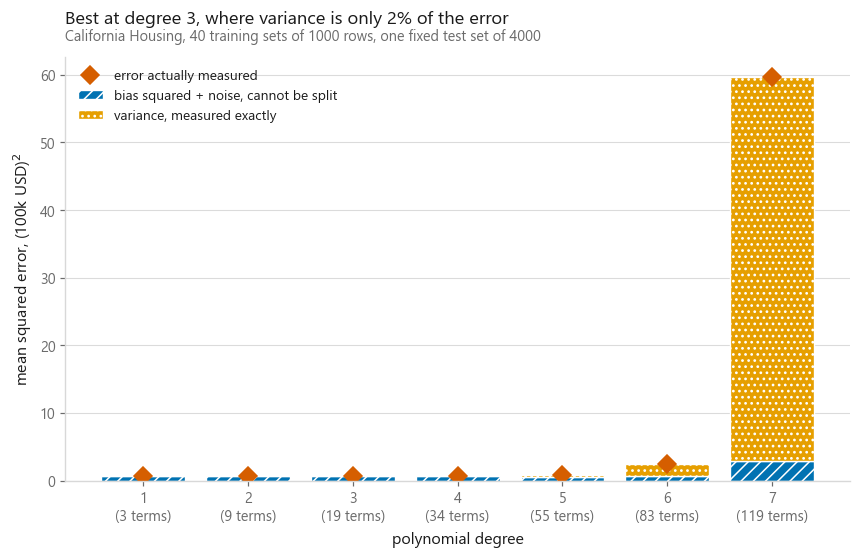

In [13]:
cal_best = cal.loc[cal["measured"].idxmin()]
var_share_best = cal_best["variance"] / cal_best["measured"]
var_share_last = cal["variance"].iloc[-1] / cal["measured"].iloc[-1]

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(cal))

ax.bar(x, cal["bias squared + noise"], color=style.PALETTE[0], hatch="///",
       edgecolor="white", linewidth=0.9, label="bias squared + noise, cannot be split")
ax.bar(x, cal["variance"], bottom=cal["bias squared + noise"], color=style.PALETTE[1],
       hatch="...", edgecolor="white", linewidth=0.9, label="variance, measured exactly")
ax.plot(x, cal["measured"], color=style.HIGHLIGHT, ls="none", marker=style.MARKERS[3],
        markersize=8, label="error actually measured")

ax.set_xticks(x, [f"{d}\n({t} terms)" for d, t in zip(cal["degree"], cal["terms"])])
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error, (100k USD)$^2$")
ax.legend(fontsize=9, loc="upper left")
style.title(
    ax,
    f"Best at degree {int(cal_best['degree'])}, where variance is only "
    f"{100 * var_share_best:.0f}% of the error",
    f"California Housing, {CAL_REPS} training sets of {CAL_N_TRAIN} rows, "
    f"one fixed test set of {len(test_y)}")
style.save(fig, FIG / "fig-05-california.png")

print(f"best degree {int(cal_best['degree'])}: measured {cal_best['measured']:.4f}, "
      f"variance share {100 * var_share_best:.1f}%")
print(f"highest degree {int(cal['degree'].iloc[-1])}: "
      f"measured {cal['measured'].iloc[-1]:.4f}, "
      f"variance share {100 * var_share_last:.1f}%")
print(f"lowest lumped bias-plus-noise seen anywhere in the sweep: "
      f"{cal['bias squared + noise'].min():.4f}")

### What changes when the truth is unavailable

Three things, and the third is the one that matters when someone shows you a
bias-variance chart on real data.

**The identity still holds exactly.** The residual column above is at floating
point noise. Nothing about the split into variance and not-variance needed the
truth, the noise level, or any distributional assumption. It is algebra applied
to a set of refits.

**The noise floor becomes a guess.** The lumped column is bounded below by the
irreducible error, so the smallest lumped value in the sweep is an upper bound
on how much of the error is model bias, and nothing more. Anyone reporting a
separate noise term on data like this has assumed one, and the honest move is
to say so rather than to print it as a measurement.

**The shape is different because the sample is different.** On the synthetic
problem the variance share ran away at high degree. Here the training sets are
larger, so the same expansion buys a variance bill that stays a minority of the
error. Which is section 6 again, on data I did not generate: the position and
depth of the U is a joint statement about the model class and the sample size,
and reporting one without the other is reporting half a result.

One more caveat specific to this dataset, and it is a good example of noise that
is not really noise. The target is capped at 5.0, and
[02-01](../01-linear-regression/) counts the districts stuck there. Error against
those rows lands in the lumped column and cannot be reduced by any model, which
makes it behave like irreducible noise. It is a recording artefact rather than
randomness, and the difference matters: real noise stays whatever you do, while
this would vanish the day someone found the uncapped file. The decomposition
cannot tell the two apart. A person reading the data documentation can, and that
is the argument for reading it.

## What I would do with this

The reason to run the decomposition rather than recite it is that the two
columns prescribe different treatments, and treating the wrong one is the most
common wasted week in applied work.

If the error is bias-dominated, more data will not help and regularisation will
hurt. The model class is too small. Add features, add interactions, add
capacity.

If the error is variance-dominated, more data helps directly, and so does
anything that constrains the fit: [ridge](../04-ridge-regression/),
[lasso](../05-lasso-regression/), fewer terms, or averaging several fits, which
is the entire reason [bagging](../../04-ensembles/01-bagging/) exists.

You do not need the synthetic ground truth to make that call. You need the
variance column, and section 7 gets it on any dataset for the price of refitting
on a few resampled training sets.

## Cheat sheet

| | |
|---|---|
| **Use it when** | The relationship is smooth and curved, the input dimension is small, and you want a model whose coefficients are still a linear solve |
| **Avoid it when** | You have many features. Terms grow like $\binom{p+d}{d}$, and the table above shows how fast that ends |
| **Always** | Scale the inputs before expanding. Raw high powers destroy the conditioning of the design |
| **Main dial** | Degree. Choose it by cross-validation, not by eye, and remember the answer depends on your sample size |
| **Bias** | The gap between the average fit and the truth. Only visible across refits. Fixed by a richer model class |
| **Variance** | The spread of fits about their own average. Only visible across refits. Fixed by more data or more constraint |
| **Noise** | Unmovable. On real data it cannot be separated from bias without repeated observations at the same input |
| **Watch out** | Variance concentrates at the edges of the training range. Never extrapolate a polynomial fit |
| **Next** | [Ridge regression](../04-ridge-regression/), which trades a little bias for a lot of variance on purpose |

## What to remember

1. Polynomial regression is linear regression with extra columns. The solver,
   the normal equation and every diagnostic from [02-01](../01-linear-regression/)
   carry over unchanged.
2. The bias-variance decomposition is an identity, not an illustration. Resample
   the training set, refit, and all three terms are computable.
3. The three terms reproduced the measured test error to within a fraction of a
   percent here, which is the check that makes the picture worth trusting.
4. The plug-in estimates of bias squared and variance are each biased, in
   opposite directions and by the same amount. Their sum is not.
5. Variance is not evenly spread. It concentrates where the data thins out,
   which on this problem is the edges of the input range.
6. The U-shaped curve is conditional on the training size. Grow the sample and
   the best degree moves right, because more data cures variance and leaves bias
   exactly where it was.
7. On real data the split into variance and everything-else is still exact and
   still free. The split of everything-else into bias and noise is not available
   without repeated measurements or an assumption.
8. Which column dominates decides what to try next. Bias-dominated error wants a
   bigger model. Variance-dominated error wants more data or more constraint.
   The chart tells you which conversation to have.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-04 Ridge regression](../04-ridge-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#PolynomialRegression` `#BiasVarianceTradeoff` `#Overfitting`
`#ScikitLearn` `#Python` `#NumPy` `#DataScience` `#MLTutorial`
`#LearnMachineLearning`